##### Copyright 2026 Google LLC.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fembeddinggemma%2Fmultimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/embeddinggemma/multimodal-embeddinggemma-with-sentence-transformers.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# Multimodal Embeddings with EmbeddingGemma 2

**EmbeddingGemma 2** is a lightweight, open-source 740M parameter model designed for unified multimodal embeddings. Built on the Gemma 4 decoder architecture, it maps **text, images, audio, and video** into a unified 768-dimensional vector space.

Because of its compact footprint, you can run demanding cross-modal workflows (e.g. cross-modal retrieval, multimedia search, and multimodal similarity) locally and offline on consumer GPUs or CPUs.

**What this guide covers:**

* Installing dependencies and loading **EmbeddingGemma 2**
* Configuring modality encoders (`vision_config` and `audio_config`) to optimize memory usage
* Generating **image embeddings** and computing image-to-image and image-to-text similarity
* Generating **audio embeddings** and matching speech/audio to text descriptions
* Generating **video embeddings** and customizing frame sampling parameters
* Combining modalities with **multimodal and interleaved inputs** (`<|image|>`, `<|audio|>`, `<|video|>`)

> **New to EmbeddingGemma 2?** See [Generating Embeddings with EmbeddingGemma 2 and Sentence Transformers](https://ai.google.dev/gemma/docs/embeddinggemma/inference-embeddinggemma-with-sentence-transformers) for core concepts including task prompts, RAG, zero-shot classification, and Matryoshka Representation Learning (MRL).

## Setup and Installation

Install `sentence-transformers`, `transformers`, and the multimedia libraries (`pillow`, `soundfile`, `torchcodec`) required for processing images, audio, and video.

Sentence Transformers is a Python framework for using and training embedding and reranker models. For more details on the framework, see the [Sentence Transformers documentation](https://www.sbert.net/).

In [ ]:
!pip install -U sentence-transformers transformers pillow soundfile torchcodec

## Model Initialization

Instantiate EmbeddingGemma 2 directly using the `SentenceTransformer` class.

### Default: Full Multimodal Setup

Initializing the model without configuration overrides automatically loads all modality encoders (text, vision, and audio), enabling full multimodal embedding generation.

In [ ]:
from sentence_transformers import SentenceTransformer

model_id = "google/embeddinggemma-2"
model = SentenceTransformer(model_id)

print(f"device: {model.device}")
print(f"dtype: {model.dtype}")
print(model)
print("Total number of parameters in the model:", sum(p.numel() for p in model.parameters()))

Loading weights:   0%|          | 0/1376 [00:00<?, ?it/s]

device: cuda:0
dtype: torch.bfloat16
SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'image': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'audio': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'video': {'method': 'forward', 'method_output_name': 'last_hidden_state'}, 'message': {'method': 'forward', 'method_output_name': 'last_hidden_state', 'format': 'structured'}}, 'module_output_name': 'token_embeddings', 'architecture': 'EmbeddingGemma2Model'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)
Total number of parameters in the model: 744371488


> **Note on Precision:** EmbeddingGemma 2 activations are incompatible with `float16`. Use `bfloat16` (default on supported GPUs) or `float32`.

### Optional: Selective Encoder Loading

If your workflow only requires specific modalities (for example, audio-only retrieval), you can selectively load only the encoders you need via `config_kwargs` to optimize memory usage and initialization speed.

Pass `"vision_config": None` and/or `"audio_config": None` when initializing the model to load only the active encoders.


In [ ]:
from sentence_transformers import SentenceTransformer

model_id = "google/embeddinggemma-2"
audio_only_model = SentenceTransformer(
    model_id,
    config_kwargs={"vision_config": None},
)

print("Total parameters (audio-only):", sum(p.numel() for p in audio_only_model.parameters()))

Loading weights:   0%|          | 0/1165 [00:00<?, ?it/s]

Total parameters (audio-only): 576613664


*(For the remainder of this tutorial, we use the full multimodal `model` initialized above.)*

## Multimodal & Cross-Modal Embeddings

Because EmbeddingGemma 2 maps all modalities into a unified 768-dimensional vector space, you can compute similarity both **within** a modality (e.g., image-to-image) and **across** modalities (e.g., text-to-image, image-to-audio, or text-to-video).

### Working with Images

Pass an image as a dictionary `{"image": <source>}`, where `<source>` can be a file path, URL, or `PIL.Image` object.

Input Image:


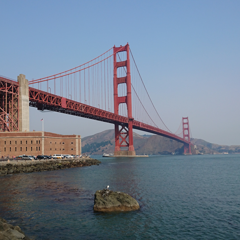


Similarity with candidates:
--------------------------------------------------------------------------------


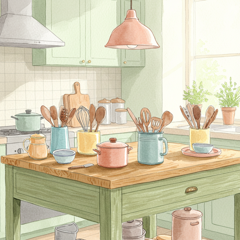

 `-> 🤖 score: 0.585

San Francisco
 `-> 🤖 score: 0.641

a cute cat walking
 `-> 🤖 score: 0.534

a friendly dog sitting in the grass
 `-> 🤖 score: 0.509



In [ ]:
from PIL import Image
from IPython.display import display
import requests

IMAGE_SIZE = 240

img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png"
input_image = Image.open(requests.get(img_url, stream=True).raw).resize((IMAGE_SIZE, IMAGE_SIZE))

print("Input Image:")
display(input_image)

# Embed the image directly from a URL, file path, or PIL Image object
emb_goldengate = model.encode({"image": img_url})

# Compare the image embedding against another image and text candidates
example_img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/kitchen_painting.jpg"
example_image = Image.open(requests.get(example_img_url, stream=True).raw).resize((IMAGE_SIZE, IMAGE_SIZE))

candidates = [
    {"image": example_img_url},
    "San Francisco",
    "a cute cat walking",
    "a friendly dog sitting in the grass",
]
emb_candidates = model.encode(candidates)
image_similarities = model.similarity(emb_goldengate, emb_candidates)[0]

print("\nSimilarity with candidates:\n"+"-"*80)
for idx, score in enumerate(image_similarities):
    if idx == 0:
        display(example_image)
    else:
        print(candidates[idx])
    print(f" `-> 🤖 score: {score:.3f}\n")

Notice that the text query `"San Francisco"` achieves the highest cross-modal similarity with the Golden Gate Bridge photo.

#### Customizing Image Processing Parameters

You can adjust vision token budget per inference call via `processing_kwargs`:

Similarity with candidates:
--------------------------------------------------------------------------------


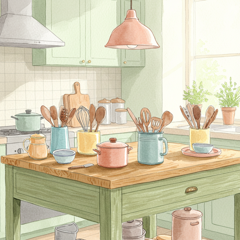

 `-> 🤖 score: 0.568

San Francisco
 `-> 🤖 score: 0.674

a cute cat walking
 `-> 🤖 score: 0.545

a friendly dog sitting in the grass
 `-> 🤖 score: 0.531



In [ ]:
img_processing_args = {
    "image": {
        "max_soft_tokens": 1120,
    }
}

emb_goldengate = model.encode({"image": img_url}, processing_kwargs=img_processing_args)
emb_candidates = model.encode(candidates, processing_kwargs=img_processing_args)
image_similarities = model.similarity(emb_goldengate, emb_candidates)[0]

print("Similarity with candidates:\n"+"-"*80)
for idx, score in enumerate(image_similarities):
    if idx == 0:
        display(example_image)
    else:
        print(candidates[idx])
    print(f" `-> 🤖 score: {score:.3f}\n")

You can decide between budget sizes of 70, 140, 280, 560, or 1120 tokens. Increasing the vision budget for input images trades latency and token count for quality.

### Working with Audio

Pass audio inputs as `{"audio": <source>}`. Supported audio sources include local file paths, URLs, or in-memory waveforms (1D/2D `float32` NumPy arrays or PyTorch tensors). Audio files are automatically decoded and resampled to 16 kHz.


In [ ]:
from IPython.display import display, Audio

aud_url = "https://ai.google.dev/gemma/docs/audio/roses-are.wav"

print("Input Audio:")
display(Audio(aud_url))

# Embed audio directly from a URL or file path
emb_speech = model.encode({"audio": aud_url})

# Compare audio embedding with text descriptions
candidates = [
    "a person speaking English",
    "random static white noise",
    "Roses are red, violets are blue.",
]
emb_candidates = model.encode(candidates)
audio_similarities = model.similarity(emb_speech, emb_candidates)[0]

print("\nSimilarity with candidates:\n"+"-"*80)
for idx, score in enumerate(audio_similarities):
    print(candidates[idx])
    print(f" `-> 🤖 score: {score:.3f}\n")

Input Audio:



Similarity with candidates:
--------------------------------------------------------------------------------
a person speaking English
 `-> 🤖 score: 0.679

random static white noise
 `-> 🤖 score: 0.651

Roses are red, violets are blue.
 `-> 🤖 score: 0.876



### Working with Video

Pass video inputs as `{"video": <source>}`. The model natively decodes MP4 files/URLs and samples video frames. You can also pass pre-extracted frames as a list of `PIL.Image` objects or 4D/5D tensors.

In [ ]:
from IPython.display import display, Video

vid_url = "https://github.com/bebechien/gemma/raw/refs/heads/main/videos/cat_dozing.mp4"

print("Input Video:")
display(Video(vid_url))

# Embed video directly from a URL or file path
emb_video = model.encode({"video": vid_url})

# Compare video embedding with text descriptions
candidates = [
    "a cat dozing",
    "a cat playing with a small lizard",
    "a sports car racing on a highway",
]
emb_candidates = model.encode(candidates)
video_similarities = model.similarity(emb_video, emb_candidates)[0]

print("\nSimilarity with candidates:\n"+"-"*80)
for idx, score in enumerate(video_similarities):
    print(candidates[idx])
    print(f" `-> 🤖 score: {score:.3f}\n")

Input Video:



Similarity with candidates:
--------------------------------------------------------------------------------
a cat dozing
 `-> 🤖 score: 0.688

a cat playing with a small lizard
 `-> 🤖 score: 0.602

a sports car racing on a highway
 `-> 🤖 score: 0.440



> **Note on FPS:** By default, video is processed as sampled frames through the vision encoder at **1 frame per second**; FPS sampling rate is configurable.

#### Customizing Video Processing Parameters

You can adjust frame sampling behavior per inference call via `processing_kwargs`:

In [ ]:
# Override video processing parameters for a specific encode() call
emb_video_custom = model.encode(
    {"video": vid_url},
    processing_kwargs={
        "video": {
            "max_frames": 16,               # Maximum frames to keep (default is 32)
            "fps": None,                    # Frames per second to extract (None keeps all up to max_frames)
            "overflow_strategy": "uniform", # How to sample when total frames exceed max_frames ('uniform' or 'truncate')
            "add_timestamps": True,         # Whether to insert frame timestamps into the multimodal sequence
        }
    },
)

video_similarities = model.similarity(emb_video_custom, emb_candidates)[0]

print("Similarity with customized video processing:\n"+"-"*80)
for idx, score in enumerate(video_similarities):
    print(candidates[idx])
    print(f" `-> 🤖 score: {score:.3f}\n")

Similarity with customized video processing:
--------------------------------------------------------------------------------
a cat dozing
 `-> 🤖 score: 0.739

a cat playing with a small lizard
 `-> 🤖 score: 0.668

a sports car racing on a highway
 `-> 🤖 score: 0.492



### Interleaved Multimodal Inputs

EmbeddingGemma 2 supports rich, mixed-modality inputs within a single query pass:

* **Multimodal dictionary:** Pass multiple keys (`"text"`, `"image"`, `"audio"`, `"video"`) in the same dictionary to combine modalities automatically.
* **Explicit placeholder interleaving:** Use `<|image|>`, `<|audio|>`, and `<|video|>` tags inside the `"text"` string to control the exact token positions where media items are inserted.


In [ ]:
img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/GoldenGate.png"
example_img_url = "https://raw.githubusercontent.com/google-gemma/cookbook/refs/heads/main/apps/sample-data/kitchen_painting.jpg"
aud_url = "https://ai.google.dev/gemma/docs/audio/roses-are.wav"
vid_url = "https://github.com/bebechien/gemma/raw/refs/heads/main/videos/cat_dozing.mp4"

# 1. Multimodal query combining text, multiple images, and audio
query_multimodal = {
    "text": "Landmark and interior photos with spoken narration",
    "image": [img_url, example_img_url],
    "audio": aud_url,
}
emb_multimodal = model.encode(query_multimodal)

# 2. Interleaved query using placeholders to specify media ordering in text
query_interleaved = {
    "text": "Compare the scene in <|video|> with <|image|> and <|image|>.",
    "image": [img_url, example_img_url],
    "video": vid_url,
}
emb_interleaved = model.encode(query_interleaved)

# 3. Media-only interleaving using placeholders to control sequence order
query_media_sequence = {
    "text": "<|image|><|audio|><|image|>",
    "image": [img_url, example_img_url],
    "audio": aud_url,
}
emb_media_sequence = model.encode(query_media_sequence)

print("Multimodal embedding shape:", emb_multimodal.shape)
print("Interleaved embedding shape:", emb_interleaved.shape)
print("Media sequence embedding shape:", emb_media_sequence.shape)

Multimodal embedding shape: (768,)
Interleaved embedding shape: (768,)
Media sequence embedding shape: (768,)


## Summary and Next Steps

You now know how to generate unified multimodal and cross-modal embeddings across **text, images, audio, and video** using **EmbeddingGemma 2** and the `sentence-transformers` library, as well as how to configure modality encoders and customize video processing parameters.

### Further Reading

* [EmbeddingGemma 2 Model Card](https://ai.google.dev/gemma/docs/embeddinggemma/model_card_2)
* [Fine-tune EmbeddingGemma with Sentence Transformers](https://ai.google.dev/gemma/docs/embeddinggemma/fine-tuning-embeddinggemma-with-sentence-transformers)
* [Vision Tune EmbeddingGemma with Sentence Transformers](https://ai.google.dev/gemma/docs/embeddinggemma/fine-tuning-multimodal-embeddinggemma-with-sentence-transformers)
* [Sentence Transformers Documentation](https://www.sbert.net/)